# RQ1: Price Gap Analysis
## Best Choice vs National Brand

---

### Research Question

**What is the price gap between Best Choice and National Brand products, and how does it compare to the target 20% gap?**

### Key Analyses

| Analysis | Description |
|----------|-------------|
| A1.1 | Distribution of price gaps across all linked products |
| A1.2 | Price gap by category |
| A1.3 | Price gap by division |
| A1.4 | Price gap trend over quarters |
| A1.5 | Identification of outliers (gaps >40% or <10%) |

### Prerequisites

> **Run `00_Data_Preparation.ipynb` first** to generate the required data files.

---

# 1. Setup

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11

# Color scheme
COLORS = {'Best Choice': '#2ecc71', 'Always Save': '#3498db', 'National Brand': '#e74c3c'}
TARGET_GAP = 20  # Target price gap percentage

print("Setup complete!")

Setup complete!


In [2]:
# =============================================================================
# LOAD PREPARED DATA (NORMALIZED - Using Unit Prices)
# =============================================================================

DATA_DIR = r'C:\Users\ashishk\Dropbox\My PC (BUS-P10E67720)\Documents\Development\AWG_Spring_26\prepared_data_normalized'

# Load BC-National comparison dataset (primary for this analysis)
df = pd.read_csv(f'{DATA_DIR}/bc_national_comparison.csv')

# Load product master for reference
df_products = pd.read_csv(f'{DATA_DIR}/product_master.csv')

print(f"BC-National Comparison data: {len(df):,} rows")
print(f"Product master: {len(df_products):,} products")
print(f"\nNote: Using NORMALIZED data with unit-level prices (BSP/Pack)")

BC-National Comparison data: 41,976 rows
Product master: 4,319 products

Note: Using NORMALIZED data with unit-level prices (BSP/Pack)


In [3]:
# =============================================================================
# DATA OVERVIEW
# =============================================================================

print("Columns available:")
print(df.columns.tolist())

print("\nData preview:")
df.head()

Columns available:
['item_code', 'division', 'quarter', 'list_cost', 'bsp', 'srp_unit_qty', 'city_srp', 'rural_srp', 'division_name', 'region', 'sales_dollars', 'sales_units', 'item_name', 'category', 'sub_category', 'brand', 'national_item_code', 'pack', 'tariff_sensitive', 'has_national_link', 'bsp_per_unit', 'list_cost_per_unit', 'is_display_item', 'unit_bsp_srp_ratio', 'national_bsp', 'national_bsp_per_unit', 'national_city_srp', 'national_pack', 'price_gap_unit_abs', 'price_gap_unit_pct', 'price_gap_case_abs', 'price_gap_case_pct', 'gap_vs_target', 'price_gap_abs', 'price_gap_pct']

Data preview:


,item_code,division,quarter,list_cost,bsp,srp_unit_qty,city_srp,rural_srp,division_name,region,sales_dollars,sales_units,item_name,category,sub_category,brand,national_item_code,pack,tariff_sensitive,has_national_link,bsp_per_unit,list_cost_per_unit,is_display_item,unit_bsp_srp_ratio,national_bsp,national_bsp_per_unit,national_city_srp,national_pack,price_gap_unit_abs,price_gap_unit_pct,price_gap_case_abs,price_gap_case_pct,gap_vs_target,price_gap_abs,price_gap_pct
0,26989,KC,Q1,NaN,NaN,NaN,NaN,NaN,Kansas City,Central,"1,765.00",802.00,BST CH HND SNTZR ALO,PERSONAL CLEANSING,HAND SANITIZERS,Best Choice,"111,218.00",1,0,1,NaN,NaN,0,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,26989,KC,Q2,NaN,NaN,NaN,NaN,NaN,Kansas City,Central,"1,552.12",667.00,BST CH HND SNTZR ALO,PERSONAL CLEANSING,HAND SANITIZERS,Best Choice,"111,218.00",1,0,1,NaN,NaN,0,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26989,KC,Q3,NaN,NaN,NaN,NaN,NaN,Kansas City,Central,"1,755.03",739.00,BST CH HND SNTZR ALO,PERSONAL CLEANSING,HAND SANITIZERS,Best Choice,"111,218.00",1,0,1,NaN,NaN,0,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,26989,KC,Q4,NaN,NaN,NaN,NaN,NaN,Kansas City,Central,"1,955.72",814.00,BST CH HND SNTZR ALO,PERSONAL CLEANSING,HAND SANITIZERS,Best Choice,"111,218.00",1,0,1,NaN,NaN,0,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,26989,SP,Q1,NaN,NaN,NaN,NaN,NaN,Springfield,Central,NaN,NaN,BST CH HND SNTZR ALO,PERSONAL CLEANSING,HAND SANITIZERS,Best Choice,"111,218.00",1,0,1,NaN,NaN,0,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# =============================================================================
# FILTER TO VALID PRICE GAP DATA
# =============================================================================

# Filter to rows with valid price gap calculations (using unit prices)
df_valid = df[
    df['price_gap_pct'].notna() & 
    (df['bsp_per_unit'] > 0) & 
    (df['national_bsp_per_unit'] > 0)
].copy()

print(f"Rows with valid price gap data: {len(df_valid):,} ({len(df_valid)/len(df)*100:.1f}%)")
print(f"Unique BC items: {df_valid['item_code'].nunique():,}")
print(f"Divisions: {df_valid['division'].nunique()}")
print(f"Quarters: {df_valid['quarter'].unique().tolist()}")
print(f"\nPrice gap calculated using: BSP per Unit (case price / pack size)")

Rows with valid price gap data: 30,924 (73.7%)
Unique BC items: 1,089
Divisions: 8
Quarters: ['Q1', 'Q2', 'Q3', 'Q4']

Price gap calculated using: BSP per Unit (case price / pack size)


---

# 2. Analysis A1.1: Price Gap Distribution

---

**Question:** What is the overall distribution of price gaps between Best Choice and National Brand products?

In [5]:
# =============================================================================
# PRICE GAP SUMMARY STATISTICS
# =============================================================================

print("="*60)
print("PRICE GAP SUMMARY STATISTICS")
print("="*60)

gap_stats = df_valid['price_gap_pct'].describe(percentiles=[.10, .25, .50, .75, .90])
print(f"\nPrice Gap (%) Statistics:")
print(gap_stats.round(2))

print(f"\n--- Key Findings ---")
print(f"Mean price gap: {df_valid['price_gap_pct'].mean():.1f}%")
print(f"Median price gap: {df_valid['price_gap_pct'].median():.1f}%")
print(f"Target gap: {TARGET_GAP}%")
print(f"Gap vs Target: {df_valid['price_gap_pct'].mean() - TARGET_GAP:+.1f}% points")

PRICE GAP SUMMARY STATISTICS

Price Gap (%) Statistics:
count   30,924.00
mean        32.27
std         15.02
min       -355.21
10%         17.99
25%         21.61
50%         30.93
75%         41.28
90%         50.62
max         93.35
Name: price_gap_pct, dtype: float64

--- Key Findings ---
Mean price gap: 32.3%
Median price gap: 30.9%
Target gap: 20%
Gap vs Target: +12.3% points


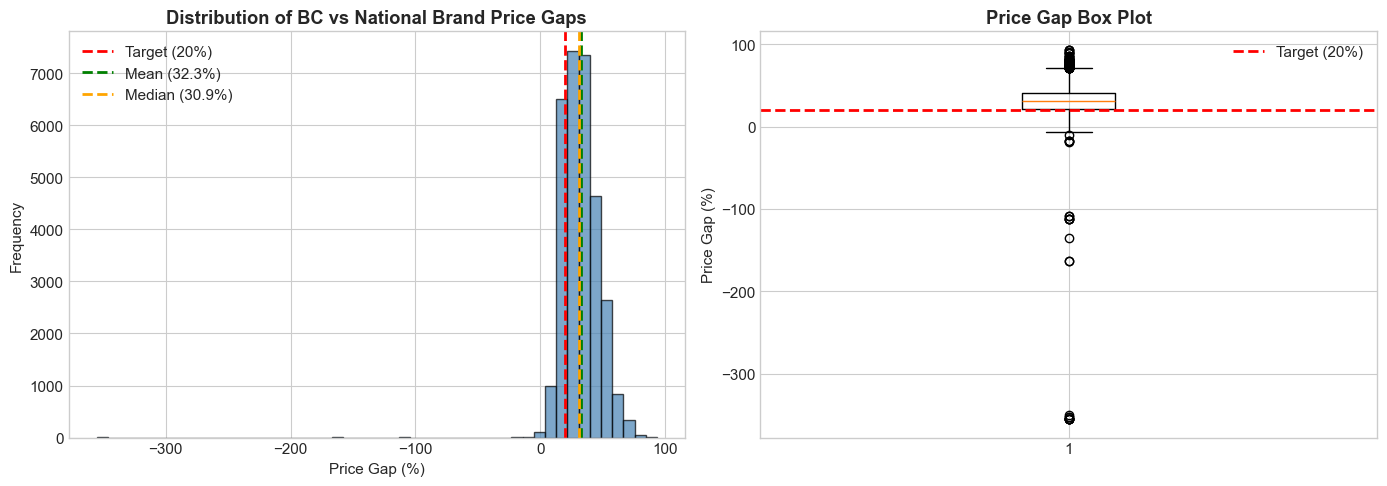


Interpretation:
- The actual price gap (32.3%) is above the 20% target
- This suggests BC products may be priced too low relative to National Brands


In [6]:
# =============================================================================
# PRICE GAP DISTRIBUTION HISTOGRAM
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_valid['price_gap_pct'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=TARGET_GAP, color='red', linestyle='--', linewidth=2, label=f'Target ({TARGET_GAP}%)')
axes[0].axvline(x=df_valid['price_gap_pct'].mean(), color='green', linestyle='--', linewidth=2, 
                label=f'Mean ({df_valid["price_gap_pct"].mean():.1f}%)')
axes[0].axvline(x=df_valid['price_gap_pct'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median ({df_valid["price_gap_pct"].median():.1f}%)')
axes[0].set_xlabel('Price Gap (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of BC vs National Brand Price Gaps', fontweight='bold')
axes[0].legend()

# Box plot
axes[1].boxplot(df_valid['price_gap_pct'].dropna(), vert=True)
axes[1].axhline(y=TARGET_GAP, color='red', linestyle='--', linewidth=2, label=f'Target ({TARGET_GAP}%)')
axes[1].set_ylabel('Price Gap (%)')
axes[1].set_title('Price Gap Box Plot', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"- The actual price gap ({df_valid['price_gap_pct'].mean():.1f}%) is {'above' if df_valid['price_gap_pct'].mean() > TARGET_GAP else 'below'} the {TARGET_GAP}% target")
print(f"- This suggests BC products may be priced {'too low' if df_valid['price_gap_pct'].mean() > TARGET_GAP else 'appropriately'} relative to National Brands")

In [7]:
# =============================================================================
# PRICE GAP CATEGORIES
# =============================================================================

# Categorize price gaps
def categorize_gap(gap):
    if gap < 10:
        return '< 10% (Too Small)'
    elif gap < 20:
        return '10-20% (Below Target)'
    elif gap < 30:
        return '20-30% (Near Target)'
    elif gap < 40:
        return '30-40% (Above Target)'
    else:
        return '> 40% (Very Large)'

df_valid['gap_category'] = df_valid['price_gap_pct'].apply(categorize_gap)

# Summary by category
gap_category_summary = df_valid['gap_category'].value_counts().sort_index()
gap_category_pct = (gap_category_summary / len(df_valid) * 100).round(1)

print("\nPrice Gap Distribution by Category:")
print("-" * 50)
for cat, count in gap_category_summary.items():
    pct = gap_category_pct[cat]
    print(f"  {cat}: {count:,} ({pct}%)")


Price Gap Distribution by Category:
--------------------------------------------------
  10-20% (Below Target): 4,939 (16.0%)
  20-30% (Near Target): 9,163 (29.6%)
  30-40% (Above Target): 7,895 (25.5%)
  < 10% (Too Small): 602 (1.9%)
  > 40% (Very Large): 8,325 (26.9%)


---

# 3. Analysis A1.2: Price Gap by Category

---

**Question:** Which product categories have the largest and smallest price gaps?

In [8]:
# =============================================================================
# PRICE GAP BY CATEGORY
# =============================================================================

# Aggregate by category
category_gaps = df_valid.groupby('category').agg({
    'price_gap_pct': ['mean', 'median', 'std', 'count'],
    'item_code': 'nunique'
}).round(2)

category_gaps.columns = ['avg_gap', 'median_gap', 'std_gap', 'observations', 'unique_items']
category_gaps = category_gaps.sort_values('avg_gap', ascending=False)

# Filter to categories with sufficient data
category_gaps_filtered = category_gaps[category_gaps['observations'] >= 20]

print(f"Categories with 20+ observations: {len(category_gaps_filtered)}")
print("\nTop 15 Categories by Average Price Gap:")
display(category_gaps_filtered.head(15))

Categories with 20+ observations: 69

Top 15 Categories by Average Price Gap:


,avg_gap,median_gap,std_gap,observations,unique_items
category,,,,,
COUGH & COLD REMEDIES,62.87,66.56,15.87,91,24
PAIN REMEDIES,58.40,62.53,11.86,86,20
SHAVING NEEDS,57.40,56.05,16.95,40,8
SOAPS & DETERGENTS,56.79,56.79,0.00,36,1
DIGESTIVE HEALTH,51.51,52.64,19.53,52,13
SKIN CARE PREPARATIONS,51.35,48.13,16.32,32,8
LAUNDRY SUPPLIES,50.74,53.83,4.33,180,5
"SALT, SEASONINGS, SPICES",49.65,56.25,14.21,769,22
CREAM CHEESE,49.65,50.04,0.83,180,5


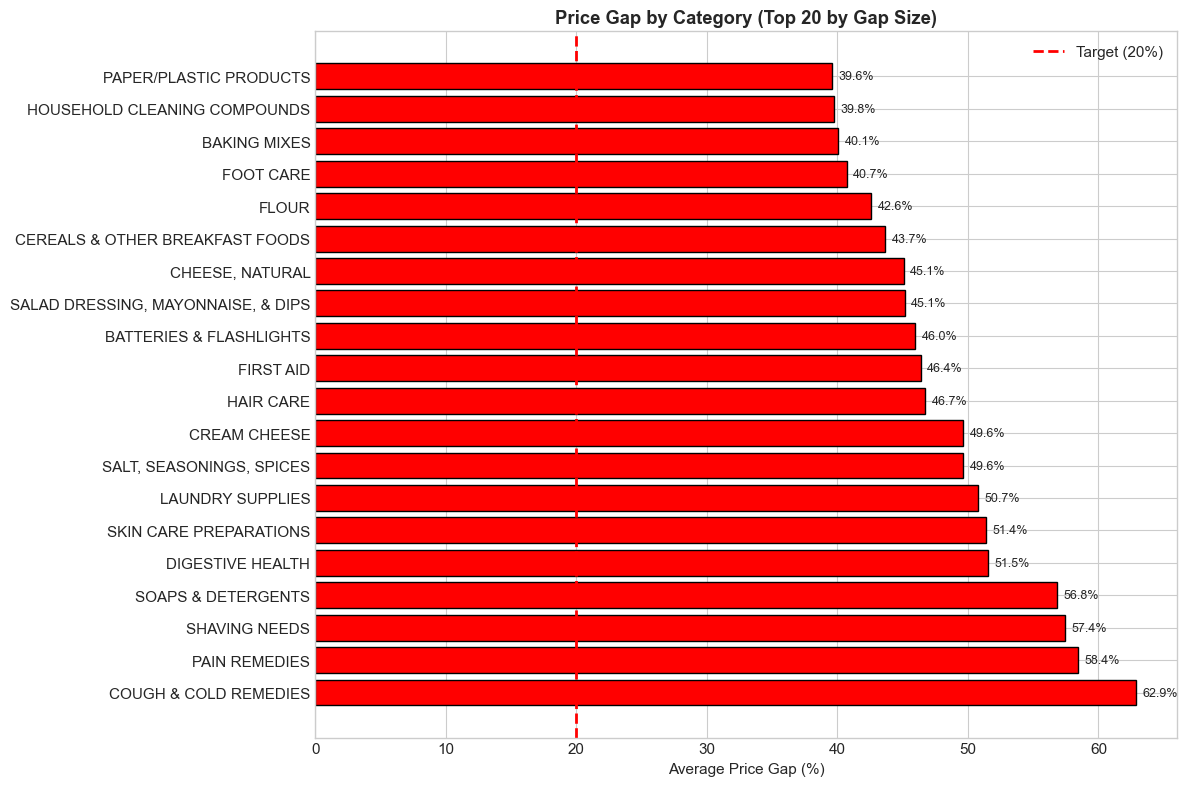

In [9]:
# =============================================================================
# PRICE GAP BY CATEGORY - VISUALIZATION
# =============================================================================

# Top 20 categories
top_categories = category_gaps_filtered.head(20)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['green' if x <= 25 else 'orange' if x <= 35 else 'red' for x in top_categories['avg_gap']]

bars = ax.barh(range(len(top_categories)), top_categories['avg_gap'], color=colors, edgecolor='black')
ax.axvline(x=TARGET_GAP, color='red', linestyle='--', linewidth=2, label=f'Target ({TARGET_GAP}%)')

ax.set_yticks(range(len(top_categories)))
ax.set_yticklabels(top_categories.index)
ax.set_xlabel('Average Price Gap (%)')
ax.set_title('Price Gap by Category (Top 20 by Gap Size)', fontweight='bold')
ax.legend()

# Add value labels
for i, v in enumerate(top_categories['avg_gap']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
# =============================================================================
# CATEGORIES CLOSEST TO TARGET (20%)
# =============================================================================

category_gaps_filtered['gap_vs_target'] = abs(category_gaps_filtered['avg_gap'] - TARGET_GAP)
closest_to_target = category_gaps_filtered.sort_values('gap_vs_target').head(10)

print("\nCategories Closest to 20% Target Gap:")
display(closest_to_target[['avg_gap', 'median_gap', 'observations', 'gap_vs_target']])


Categories Closest to 20% Target Gap:


,avg_gap,median_gap,observations,gap_vs_target
category,,,,
FROZEN BAKED GOODS,20.47,19.91,223,0.47
"FRUIT, DRIED",19.48,19.48,72,0.52
"PEANUT BUTTER, JELLY & SPREADS",18.73,18.91,742,1.27
ICE CREAM NOVELTIES,21.36,19.87,198,1.36
ORAL HYGIENE,21.61,57.67,44,1.61
FROZEN JUICES & DRINKS,21.86,18.10,120,1.86
PASTA & NOODLES,17.94,17.94,68,2.06
MILK/MILK SUBS/SOY,17.81,18.90,36,2.19
"FRUIT, CANNED, GLASS & PLASTIC",22.47,20.10,1300,2.47


---

# 4. Analysis A1.3: Price Gap by Division

---

**Question:** How do price gaps vary across AWG's geographic divisions?

In [11]:
# =============================================================================
# PRICE GAP BY DIVISION
# =============================================================================

division_gaps = df_valid.groupby('division').agg({
    'price_gap_pct': ['mean', 'median', 'std'],
    'item_code': 'nunique'
}).round(2)

division_gaps.columns = ['avg_gap', 'median_gap', 'std_gap', 'unique_items']
division_gaps = division_gaps.sort_values('avg_gap', ascending=False)

# Add division names
DIVISIONS = {
    'KC': 'Kansas City', 'SP': 'Springfield', 'OK': 'Oklahoma',
    'NA': 'Nashville', 'GC': 'Gulf Coast', 'NE': 'Nebraska',
    'GL': 'Great Lakes', 'HN': 'Hernando', 'UM': 'Upper Midwest'
}
division_gaps['division_name'] = division_gaps.index.map(DIVISIONS)

print("Price Gap by Division:")
display(division_gaps)

Price Gap by Division:


,avg_gap,median_gap,std_gap,unique_items,division_name
division,,,,,
HN,33.40,32.51,24.95,956,Hernando
UM,32.37,30.91,12.85,760,Upper Midwest
NE,32.21,30.73,12.74,762,Nebraska
GC,32.18,31.02,13.13,824,Gulf Coast
GL,32.17,30.73,13.10,788,Great Lakes
SP,32.11,30.67,12.74,793,Springfield
OK,31.98,30.67,12.81,800,Oklahoma
KC,31.86,30.52,12.80,817,Kansas City


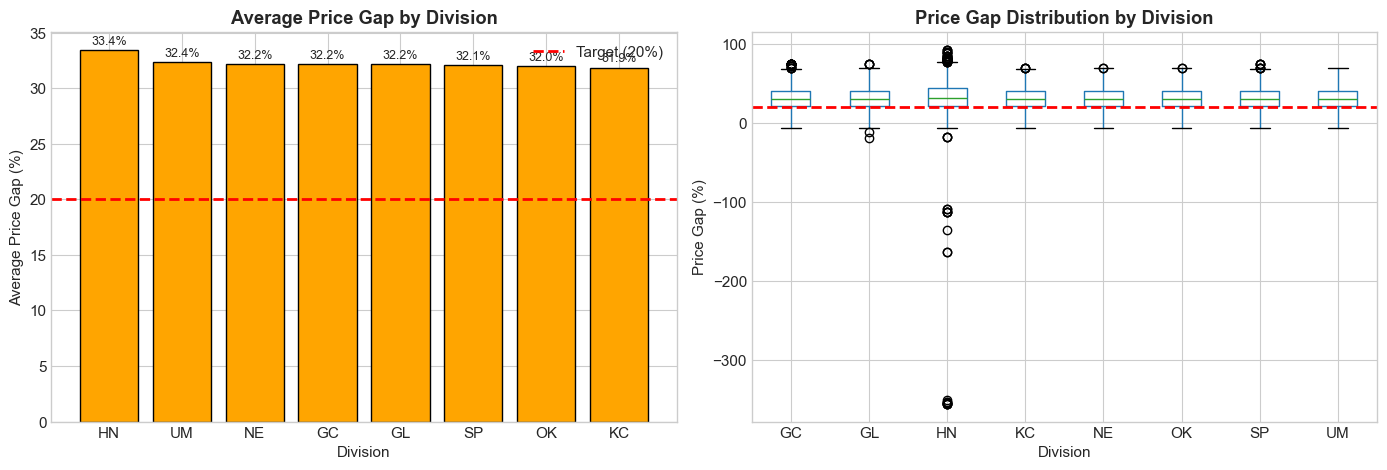


Key Finding:
Division gap range: 1.5% points (from 31.9% to 33.4%)


In [12]:
# =============================================================================
# PRICE GAP BY DIVISION - VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['green' if x <= 25 else 'orange' if x <= 35 else 'red' for x in division_gaps['avg_gap']]
axes[0].bar(division_gaps.index, division_gaps['avg_gap'], color=colors, edgecolor='black')
axes[0].axhline(y=TARGET_GAP, color='red', linestyle='--', linewidth=2, label=f'Target ({TARGET_GAP}%)')
axes[0].set_xlabel('Division')
axes[0].set_ylabel('Average Price Gap (%)')
axes[0].set_title('Average Price Gap by Division', fontweight='bold')
axes[0].legend()

# Add value labels
for i, (div, gap) in enumerate(zip(division_gaps.index, division_gaps['avg_gap'])):
    axes[0].text(i, gap + 0.5, f'{gap:.1f}%', ha='center', fontsize=9)

# Box plot by division
division_order = division_gaps.index.tolist()
df_valid['division_ordered'] = pd.Categorical(df_valid['division'], categories=division_order, ordered=True)
df_valid.boxplot(column='price_gap_pct', by='division', ax=axes[1])
axes[1].axhline(y=TARGET_GAP, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Division')
axes[1].set_ylabel('Price Gap (%)')
axes[1].set_title('Price Gap Distribution by Division', fontweight='bold')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

print("\nKey Finding:")
gap_range = division_gaps['avg_gap'].max() - division_gaps['avg_gap'].min()
print(f"Division gap range: {gap_range:.1f}% points (from {division_gaps['avg_gap'].min():.1f}% to {division_gaps['avg_gap'].max():.1f}%)")

---

# 5. Analysis A1.4: Price Gap Trend Over Quarters

---

**Question:** How has the price gap changed throughout the year?

In [13]:
# =============================================================================
# PRICE GAP BY QUARTER
# =============================================================================

quarter_gaps = df_valid.groupby('quarter').agg({
    'price_gap_pct': ['mean', 'median', 'std'],
    'item_code': 'nunique'
}).round(2)

quarter_gaps.columns = ['avg_gap', 'median_gap', 'std_gap', 'unique_items']

print("Price Gap by Quarter:")
display(quarter_gaps)

Price Gap by Quarter:


,avg_gap,median_gap,std_gap,unique_items
quarter,,,,
Q1,31.84,31.08,15.52,1071
Q2,32.04,30.20,15.62,1073
Q3,32.39,30.67,15.61,1076
Q4,32.81,31.29,13.19,1087


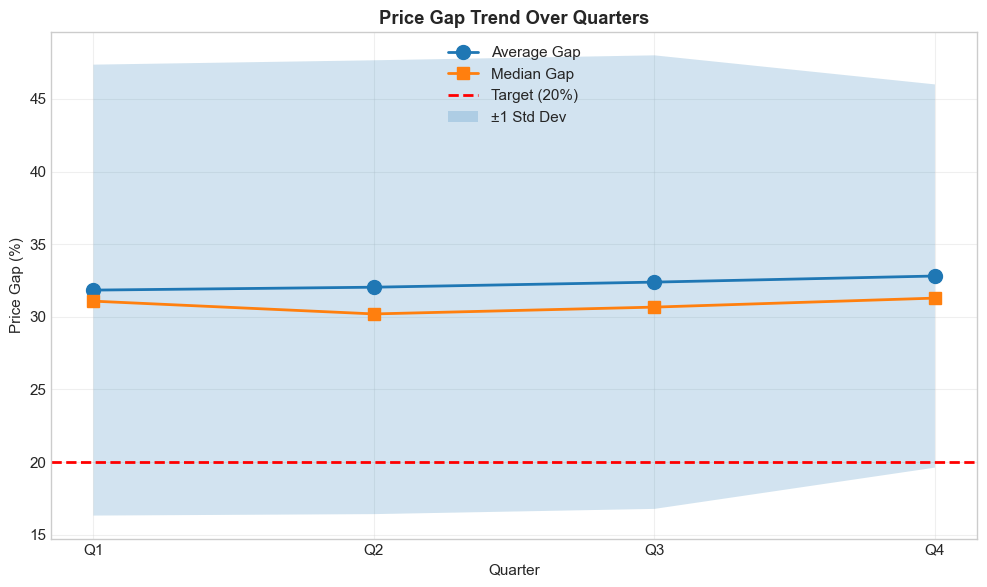


Q1 to Q4 Change: +1.0% points
  Q1 average gap: 31.8%
  Q4 average gap: 32.8%


In [14]:
# =============================================================================
# PRICE GAP TREND VISUALIZATION
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

quarters = ['Q1', 'Q2', 'Q3', 'Q4']
quarter_gaps_ordered = quarter_gaps.reindex(quarters)

ax.plot(quarters, quarter_gaps_ordered['avg_gap'], marker='o', linewidth=2, markersize=10, label='Average Gap')
ax.plot(quarters, quarter_gaps_ordered['median_gap'], marker='s', linewidth=2, markersize=8, label='Median Gap')
ax.axhline(y=TARGET_GAP, color='red', linestyle='--', linewidth=2, label=f'Target ({TARGET_GAP}%)')

ax.fill_between(quarters, 
                quarter_gaps_ordered['avg_gap'] - quarter_gaps_ordered['std_gap'],
                quarter_gaps_ordered['avg_gap'] + quarter_gaps_ordered['std_gap'],
                alpha=0.2, label='±1 Std Dev')

ax.set_xlabel('Quarter')
ax.set_ylabel('Price Gap (%)')
ax.set_title('Price Gap Trend Over Quarters', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate Q1 to Q4 change
if 'Q1' in quarter_gaps_ordered.index and 'Q4' in quarter_gaps_ordered.index:
    q1_gap = quarter_gaps_ordered.loc['Q1', 'avg_gap']
    q4_gap = quarter_gaps_ordered.loc['Q4', 'avg_gap']
    change = q4_gap - q1_gap
    print(f"\nQ1 to Q4 Change: {change:+.1f}% points")
    print(f"  Q1 average gap: {q1_gap:.1f}%")
    print(f"  Q4 average gap: {q4_gap:.1f}%")

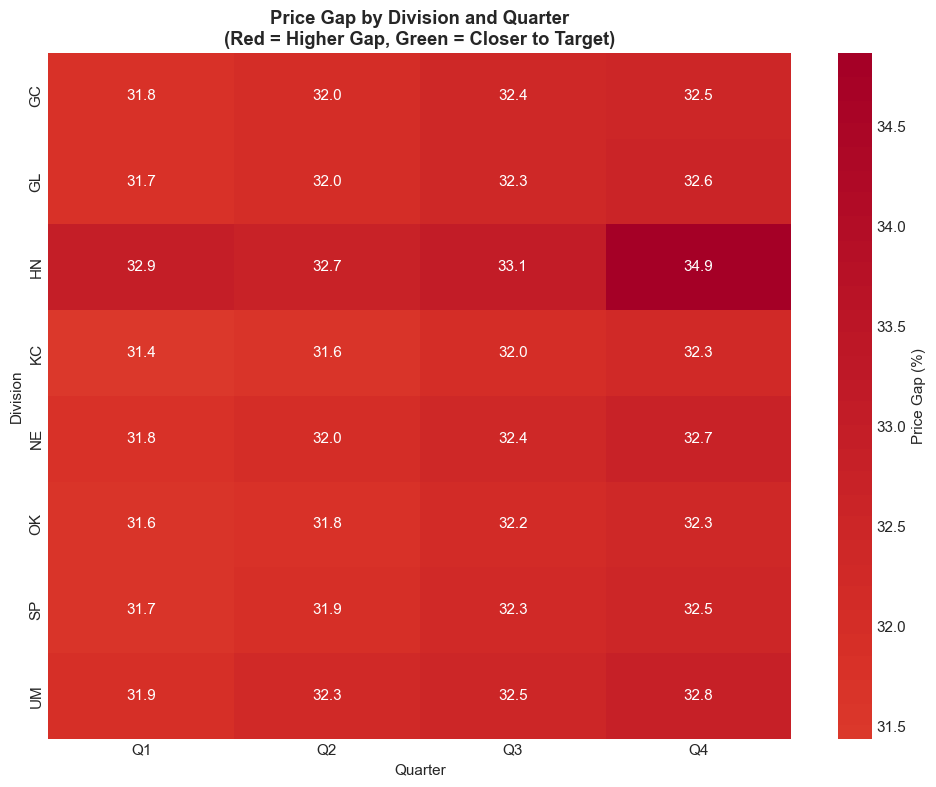

In [15]:
# =============================================================================
# PRICE GAP TREND BY DIVISION
# =============================================================================

# Pivot for heatmap
gap_pivot = df_valid.pivot_table(
    values='price_gap_pct',
    index='division',
    columns='quarter',
    aggfunc='mean'
).reindex(columns=['Q1', 'Q2', 'Q3', 'Q4'])

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(gap_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            center=TARGET_GAP, cbar_kws={'label': 'Price Gap (%)'}, ax=ax)

ax.set_title('Price Gap by Division and Quarter\n(Red = Higher Gap, Green = Closer to Target)', fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Division')

plt.tight_layout()
plt.show()

---

# 6. Analysis A1.5: Outlier Identification

---

**Question:** Which products have unusually large (>40%) or small (<10%) price gaps?

In [16]:
# =============================================================================
# IDENTIFY OUTLIERS
# =============================================================================

# Very large gaps (>40%)
large_gaps = df_valid[df_valid['price_gap_pct'] > 40].copy()

# Very small gaps (<10%)
small_gaps = df_valid[df_valid['price_gap_pct'] < 10].copy()

# Negative gaps (BC more expensive than National!)
negative_gaps = df_valid[df_valid['price_gap_pct'] < 0].copy()

print("="*60)
print("OUTLIER SUMMARY")
print("="*60)
print(f"\nLarge gaps (>40%): {len(large_gaps):,} observations ({len(large_gaps)/len(df_valid)*100:.1f}%)")
print(f"Small gaps (<10%): {len(small_gaps):,} observations ({len(small_gaps)/len(df_valid)*100:.1f}%)")
print(f"Negative gaps (BC > National): {len(negative_gaps):,} observations ({len(negative_gaps)/len(df_valid)*100:.1f}%)")

OUTLIER SUMMARY

Large gaps (>40%): 8,325 observations (26.9%)
Small gaps (<10%): 602 observations (1.9%)
Negative gaps (BC > National): 40 observations (0.1%)


In [17]:
# =============================================================================
# SAMPLE LARGE GAP ITEMS
# =============================================================================

if len(large_gaps) > 0:
    print("\nSample Items with Large Price Gaps (>40%):")
    print("-" * 80)
    
    large_gap_sample = large_gaps.groupby('item_code').agg({
        'item_name': 'first',
        'category': 'first',
        'bsp': 'mean',
        'national_bsp': 'mean',
        'price_gap_pct': 'mean'
    }).sort_values('price_gap_pct', ascending=False).head(15)
    
    large_gap_sample.columns = ['Item Name', 'Category', 'BC BSP', 'National BSP', 'Gap %']
    display(large_gap_sample)


Sample Items with Large Price Gaps (>40%):
--------------------------------------------------------------------------------


,Item Name,Category,BC BSP,National BSP,Gap %
item_code,,,,,
702159,BST CH DNDRF SHP 2N1,HAIR CARE,3.31,31.73,89.53
701896,BST CH MW BLUE MINT,ORAL HYGIENE,6.28,39.84,84.24
759456,BST CH TWN BLAD PLUS,SHAVING NEEDS,10.35,29.75,82.61
200945,BST CH WHL MTH CL TB,ORAL HYGIENE,6.67,35.74,81.32
27343,BST CH LPRMID 2MG SG,DIGESTIVE HEALTH,13.76,71.33,80.70
43107,BST CH FACE CLEANSER,SKIN CARE PREPARATIONS,7.00,34.82,79.91
700232,BST CH MUCUS RLF SVR,COUGH & COLD REMEDIES,15.84,39.43,79.91
700202,BST CH MUCS CLD FLU,COUGH & COLD REMEDIES,15.84,39.43,79.91
702053,BST CH MCS SVR SN CN,COUGH & COLD REMEDIES,16.11,39.43,79.58


In [18]:
# =============================================================================
# SAMPLE SMALL/NEGATIVE GAP ITEMS
# =============================================================================

if len(small_gaps) > 0:
    print("\nSample Items with Small Price Gaps (<10%):")
    print("-" * 80)
    
    small_gap_sample = small_gaps.groupby('item_code').agg({
        'item_name': 'first',
        'category': 'first',
        'bsp': 'mean',
        'national_bsp': 'mean',
        'price_gap_pct': 'mean'
    }).sort_values('price_gap_pct', ascending=True).head(15)
    
    small_gap_sample.columns = ['Item Name', 'Category', 'BC BSP', 'National BSP', 'Gap %']
    display(small_gap_sample)


Sample Items with Small Price Gaps (<10%):
--------------------------------------------------------------------------------


,Item Name,Category,BC BSP,National BSP,Gap %
item_code,,,,,
620024,BST CH LHS RFL ALOE,PERSONAL CLEANSING,19.20,6.34,-354.26
620034,BST CH LHS RFL CLEAR,PERSONAL CLEANSING,19.20,6.34,-354.26
32995,BST CH LHS RFL AB,PERSONAL CLEANSING,19.15,6.34,-353.15
701938,BST CH MW FRSH MINT,ORAL HYGIENE,1.39,3.29,-153.50
780700,BST CH MW SPRNG MNT,ORAL HYGIENE,7.20,5.13,-110.66
780692,BST CH MW BLU MINT,ORAL HYGIENE,7.20,5.13,-110.66
916981,BST CH SUPER GLU 2GR,HARDWARE & TOOLS,0.96,0.82,-17.07
352732,BST CH NAVY BEANS,"VEGETABLES, DRIED",23.75,21.56,-10.38
353078,BST CH BLACK BEANS,"VEGETABLES, DRIED",24.16,23.73,-1.82


In [19]:
# =============================================================================
# CATEGORIES WITH MOST OUTLIERS
# =============================================================================

print("\nCategories with Most Large Gap Items (>40%):")
if len(large_gaps) > 0:
    large_gap_categories = large_gaps.groupby('category')['item_code'].nunique().sort_values(ascending=False).head(10)
    print(large_gap_categories.to_string())

print("\nCategories with Most Small Gap Items (<10%):")
if len(small_gaps) > 0:
    small_gap_categories = small_gaps.groupby('category')['item_code'].nunique().sort_values(ascending=False).head(10)
    print(small_gap_categories.to_string())


Categories with Most Large Gap Items (>40%):
category
PAPER/PLASTIC PRODUCTS                           28
CEREALS & OTHER BREAKFAST FOODS                  25
VEGETABLES, SHELF STABLE                         21
COUGH & COLD REMEDIES                            21
CHEESE, NATURAL                                  18
SALAD DRESSING, MAYONNAISE, & DIPS               18
PAIN REMEDIES                                    18
COOKIES - CRACKERS - MISCELLANEOUS BREAD PROD    16
SALT, SEASONINGS, SPICES                         15
CONDIMENTS & SAUCES                              13

Categories with Most Small Gap Items (<10%):
category
PERSONAL CLEANSING                5
SNACKS                            3
ORAL HYGIENE                      3
PAPER/PLASTIC PRODUCTS            3
PEANUT BUTTER, JELLY & SPREADS    3
FROZEN VEGETABLES                 3
CONDIMENTS & SAUCES               2
VEGETABLES, DRIED                 2
TORTILLAS                         2
PICKLES, OLIVES, RELISHES         2


---

# 7. Summary & Key Findings

---

In [20]:
# =============================================================================
# EXECUTIVE SUMMARY
# =============================================================================

print("="*70)
print("RQ1: PRICE GAP ANALYSIS - EXECUTIVE SUMMARY")
print("="*70)

print("\n1. OVERALL PRICE GAP")
print(f"   - Average gap: {df_valid['price_gap_pct'].mean():.1f}%")
print(f"   - Median gap: {df_valid['price_gap_pct'].median():.1f}%")
print(f"   - Target gap: {TARGET_GAP}%")
print(f"   - Status: {'ABOVE' if df_valid['price_gap_pct'].mean() > TARGET_GAP else 'BELOW'} TARGET by {abs(df_valid['price_gap_pct'].mean() - TARGET_GAP):.1f}% points")

print("\n2. CATEGORY VARIATION")
print(f"   - Categories analyzed: {len(category_gaps_filtered)}")
print(f"   - Highest gap category: {category_gaps_filtered.index[0]} ({category_gaps_filtered['avg_gap'].iloc[0]:.1f}%)")
print(f"   - Lowest gap category: {category_gaps_filtered.index[-1]} ({category_gaps_filtered['avg_gap'].iloc[-1]:.1f}%)")

print("\n3. GEOGRAPHIC VARIATION")
print(f"   - Highest gap division: {division_gaps.index[0]} ({division_gaps['avg_gap'].iloc[0]:.1f}%)")
print(f"   - Lowest gap division: {division_gaps.index[-1]} ({division_gaps['avg_gap'].iloc[-1]:.1f}%)")
print(f"   - Division range: {division_gaps['avg_gap'].max() - division_gaps['avg_gap'].min():.1f}% points")

print("\n4. OUTLIERS")
print(f"   - Items with gap >40%: {len(large_gaps):,} observations")
print(f"   - Items with gap <10%: {len(small_gaps):,} observations")
print(f"   - Items with negative gap: {len(negative_gaps):,} observations")

print("\n5. RECOMMENDATIONS")
print("   - Review categories with gaps significantly above 40%")
print("   - Investigate items with negative gaps (BC priced above National)")
print("   - Consider division-specific pricing strategies")
print("   - Monitor quarterly trends for pricing alignment")

RQ1: PRICE GAP ANALYSIS - EXECUTIVE SUMMARY

1. OVERALL PRICE GAP
   - Average gap: 32.3%
   - Median gap: 30.9%
   - Target gap: 20%
   - Status: ABOVE TARGET by 12.3% points

2. CATEGORY VARIATION
   - Categories analyzed: 69
   - Highest gap category: COUGH & COLD REMEDIES (62.9%)
   - Lowest gap category: PERSONAL CLEANSING (-55.8%)

3. GEOGRAPHIC VARIATION
   - Highest gap division: HN (33.4%)
   - Lowest gap division: KC (31.9%)
   - Division range: 1.5% points

4. OUTLIERS
   - Items with gap >40%: 8,325 observations
   - Items with gap <10%: 602 observations
   - Items with negative gap: 40 observations

5. RECOMMENDATIONS
   - Review categories with gaps significantly above 40%
   - Investigate items with negative gaps (BC priced above National)
   - Consider division-specific pricing strategies
   - Monitor quarterly trends for pricing alignment


---

# End of RQ1 Analysis

---

**Next:** Proceed to `RQ2_Cost_Pass_Through.ipynb` for cost pass-through analysis.